# 📄 SOTA Universal NLP Engine — Syntax Guide & Protocol

This notebook orchestrates the `AutoMLFactory` for **text intelligence** workloads. The engine supports **three distinct NLP modes**, automatically routed by the `AUTOML_CONFIG` dictionary.

> **Important**: Your raw text can be dirty — the engine applies a **production-grade 15-step Text Cleanliness Guard** that handles HTML, URLs, emojis, Indonesian slang, English slang, repeated characters, and more. The CSV must simply be structurally valid with a well-defined text column. **No language specification is needed** — language is auto-detected.

---

## 🧠 Task Mode Routing Logic

The engine determines the NLP mode automatically based on configuration keys:

| Priority | Condition | Routed Mode | Backend |
|:---|:---|:---|:---|
| 1 | `target_column` is set (non-empty) | **Supervised** | AutoGluon Tabular + BGE-M3 Embeddings |
| 2 | `candidate_labels` is set (list of strings) | **Zero-Shot** | HuggingFace `mDeBERTa-v3-base-xnli-multilingual-nli-2mil7` |
| 3 | Neither target nor labels provided | **Unsupervised** | BERTopic + BGE-M3 Embeddings |

---

## 📜 The Configuration Schema

The `AUTOML_CONFIG` dictionary defines the engine's behavior. Below are the keys strictly related to `task_type = "nlp"`.

| Key | Type | Description | Available Options | Example |
|:---|:---|:---|:---|:---|
| `experiment_name` | `str` | MLflow experiment identifier. | Any string | `"Sentiment_Analysis"` |
| `task_type` | `str` | ML task routing. Must be `"nlp"`. | `"nlp"` | `"nlp"` |
| `dataset_path` | `str` | Path to dataset CSV with text features. | Any valid path | `"Dataset/reviews.csv"` |
| `features` | `List[str]` | Columns to use as tabular features alongside text embeddings (Supervised mode only). Empty `[]` uses all columns. | List of column names, `[]` | `[]` |
| `exclude_features` | `List[str]` | Columns to explicitly exclude. Protected columns (text_column, target) are never dropped. | List of column names, `[]` | `["source_url"]` |
| `text_column` | `str` | **(Required)** Column containing raw text. | Column name in dataset | `"review_body"` |
| `target_column` | `str` | Label column for **Supervised** mode. Omit or set `""` for Zero-Shot/Unsupervised. | Column name, `""` | `"sentiment"` |
| `candidate_labels` | `List[str]` | Candidate labels for **Zero-Shot** classification. Only used when `target_column` is empty. | List of label strings, `None` | `["positive", "negative", "neutral"]` |
| `presets` | `str` | Supervised training preset (maps to AutoGluon Tabular + BGE-M3 Embeddings). | `"extreme"`, `"best"`, `"high"`, `"medium"` | `"medium"` |
| `time_limit_seconds` | `int` | Maximum training time limit allowed in seconds. | Any positive integer | `300` |
| `calibrate_decision_threshold` | `bool` | Calibrate decision threshold (binary classification only). | `True`, `False` | `False` |
| `auto_stack` | `bool` | Auto-stack ensemble models for boosted performance. | `True`, `False` | `False` |
| `nlp_embedding_batch_size` | `int` | Batch size for BGE-M3 embedding extraction (Unsupervised). | Any positive integer | `16` |
| `nlp_zero_shot_batch_size` | `int` | Batch size for Zero-Shot inference pipeline. | Any positive integer | `8` |
| `base_output_dir` | `str` | Centralized artifact output root directory. | Any valid directory path | `"automl_nlp_run"` |
| `prediction_data_path` | `str` | Path to unseen text data for batch inference (Supervised mode only). | Any valid path, `None` | `None` |
| `fast_dev_run` | `bool` | Quick prototyping mode (subsamples data). | `True`, `False` | `False` |
| `ai_context` | `str` | Business context string to guide the AI natural language report summary. | Any string, `None` | `"Classifying customer support tickets and modeling themes from user feedback."` |

### 🚫 Strict Rules
1. **Text Column Required**: `text_column` must always be specified and must exist in the dataset.
2. **Mutual Exclusivity**: `target_column` and `candidate_labels` should not both be set. If `target_column` is present, it takes priority (Supervised mode).
| `prediction_data_path` | `str` | Path to unseen text data for batch inference (Supervised mode only; redundant for Zero-Shot and Unsupervised modes since they run directly on the training dataset). | Any valid path, `None` | `None` |
4. **Embedding Model**: Unsupervised mode uses `BAAI/bge-m3` (1024-dim) embeddings. The model is cached in `{base_output_dir}/models_nlp/bge_m3_cache/`.
5. **GPU Awareness**: All three modes auto-detect CUDA availability and route inference to GPU when available.

### 📋 Blank Configuration Template

Copy this block and customize for your dataset:

```python
AUTOML_CONFIG = {
    # ── Core Pipeline Settings ──────────────────────────────────────
    "experiment_name": "NLP_Experiment",
    "task_type": "nlp",
    "dataset_path": "Dataset/your_file.csv",
    "text_column": "your_text_column",      # Column with raw text
    "target_column": [],                    # Empty [] triggers Unsupervised mode
    "features": [],                        # Empty [] uses all columns (Supervised only)
    "exclude_features": [],                # Columns to explicitly exclude
    "candidate_labels": None,              # List[str] — candidate labels for Zero-Shot mode

    # ── Model Training & Metrics ────────────────────────────────────
    "presets": "medium",
    "time_limit_seconds": 600,
    "calibrate_decision_threshold": False,  # Calibrate threshold (supervised binary classification only)
    "auto_stack": False,                    # Enable ensemble stacking for supervised models
    "nlp_embedding_batch_size": 16,         # Batch size for embedding extraction
    "nlp_zero_shot_batch_size": 8,          # Batch size for zero-shot inference pipeline

    # ── Infrastructure & Inference ──────────────────────────────────
    "base_output_dir": "automl_run",
    "prediction_data_path": None,          # Path to unseen data (Supervised mode only)
    "fast_dev_run": False,                  # Set False for production runs

    # ── AI Audit Narrative ──────────────────────────────────────────
    "ai_context": "Classifying customer support tickets and modeling themes from user feedback."
}
```


---
## ⚙️ Step 1: Pipeline Configuration
Customize the dictionary below for your dataset and experiment. The routing mode is determined automatically based on the presence of `target_column` and `candidate_labels`.

In [1]:
# ══════════════════════════════════════════════════════════════════════
#  Pipeline Configuration
# ══════════════════════════════════════════════════════════════════════

AUTOML_CONFIG = {
    # ── Core Pipeline Settings ──────────────────────────────────────
    "experiment_name": "NLP_Run",
    "task_type": "nlp",
    "dataset_path": "dummy_dataset/nlp_unsupervised.csv",
    "text_column": "doc_text",              # Column containing raw text
    "target_column": [],                    # Empty [] triggers Unsupervised mode
    "features": [],                         # Empty [] uses all columns (Supervised only)
    "exclude_features": [],                 # Columns to explicitly exclude
    "candidate_labels": [],                 # Empty/None for unsupervised topic modeling

    # ── Model Training & Metrics ────────────────────────────────────
    "presets": "medium",
    "time_limit_seconds": 120,
    "calibrate_decision_threshold": False,  # Calibrate threshold (supervised binary classification only)
    "auto_stack": False,                    # Enable ensemble stacking for supervised models
    "nlp_embedding_batch_size": 8,         # Batch size for embedding extraction
    "nlp_zero_shot_batch_size": 8,          # Batch size for zero-shot inference pipeline

    # ── Infrastructure & Inference ──────────────────────────────────
    "base_output_dir": "Experiments/ml_nlp",
    "prediction_data_path": None,          # Path to unseen data (Supervised mode only)
    "fast_dev_run": False,

    # ── AI Audit Narrative ──────────────────────────────────────────
    "ai_context": "Classifying customer support tickets and modeling themes from user feedback."
}


---
## 🚀 Step 2: Execute Engine
This orchestrates text cleaning (15-step guard), language detection, embedding extraction, model training (or zero-shot inference), evaluation, plot generation, MLflow logging, and the premium HTML dashboard — all automatically based on the routing mode.

Topic,Count,Name,Representation,Representative Docs
-1,4,Outliers,"['2026 healthy', '2026 healthy bowls', '5g', '5g kotakota', 'developer indonesia', '5g kotakota tier', 'bowls', 'bowls matcha', 'bowls matcha everything', 'captured']","['infrastruktur digital indonesia semakin membaik dengan perluasan jaringan 5g ke kota-kota tier 2', 'trend kuliner 2026: healthy bowls, matcha everything, dan street food fusion indo-korean', 'the james webb space telescope captured new images of distant galaxies forming in the early universe']"
0,19,AI Driven Predictive Disease Modeling,"['learning', 'models', 'data', 'improved', 'disease', 'algorithms', 'complex', 'enables', 'applications', 'ai']","['graphql provides a more efficient alternative to rest apis for complex data fetching requirements', 'the latest iphone 16 features a titanium body with improved camera system and a18 chip', 'natural language processing models like bert and gpt have transformed how machines understand human language']"
1,18,Proyeksi Pertumbuhan Ekonomi Indonesia 2026,"['indonesia', '2026', 'baru', 'global', 'didorong', 'naik', 'pemerintah', 'tinggi', '30', 'including']","['cuaca ekstrem melanda beberapa wilayah jawa barat, bmkg imbau warga waspada banjir', 'climate change is causing more frequent extreme weather events including floods and droughts worldwide', 'renewable energy sources including solar and wind now account for 30% of global electricity generation']"
2,10,Panduan Praktis Kuliner dan Minuman,"['cara', 'tips', 'bawang', 'cendol', 'es', 'kecil', 'kopi', 'gula', 'merah', 'nasi']","['tips diet sehat: kurangi gula, perbanyak sayur dan buah, olahraga rutin minimal 30 menit/hari', 'cara merawat tanaman hias: siram 2x sehari, kasih pupuk tiap 2 minggu, taruh di tempat teduh', 'resep es cendol: campurkan cendol, santan, gula merah cair, dan es batu. seger banget!']"

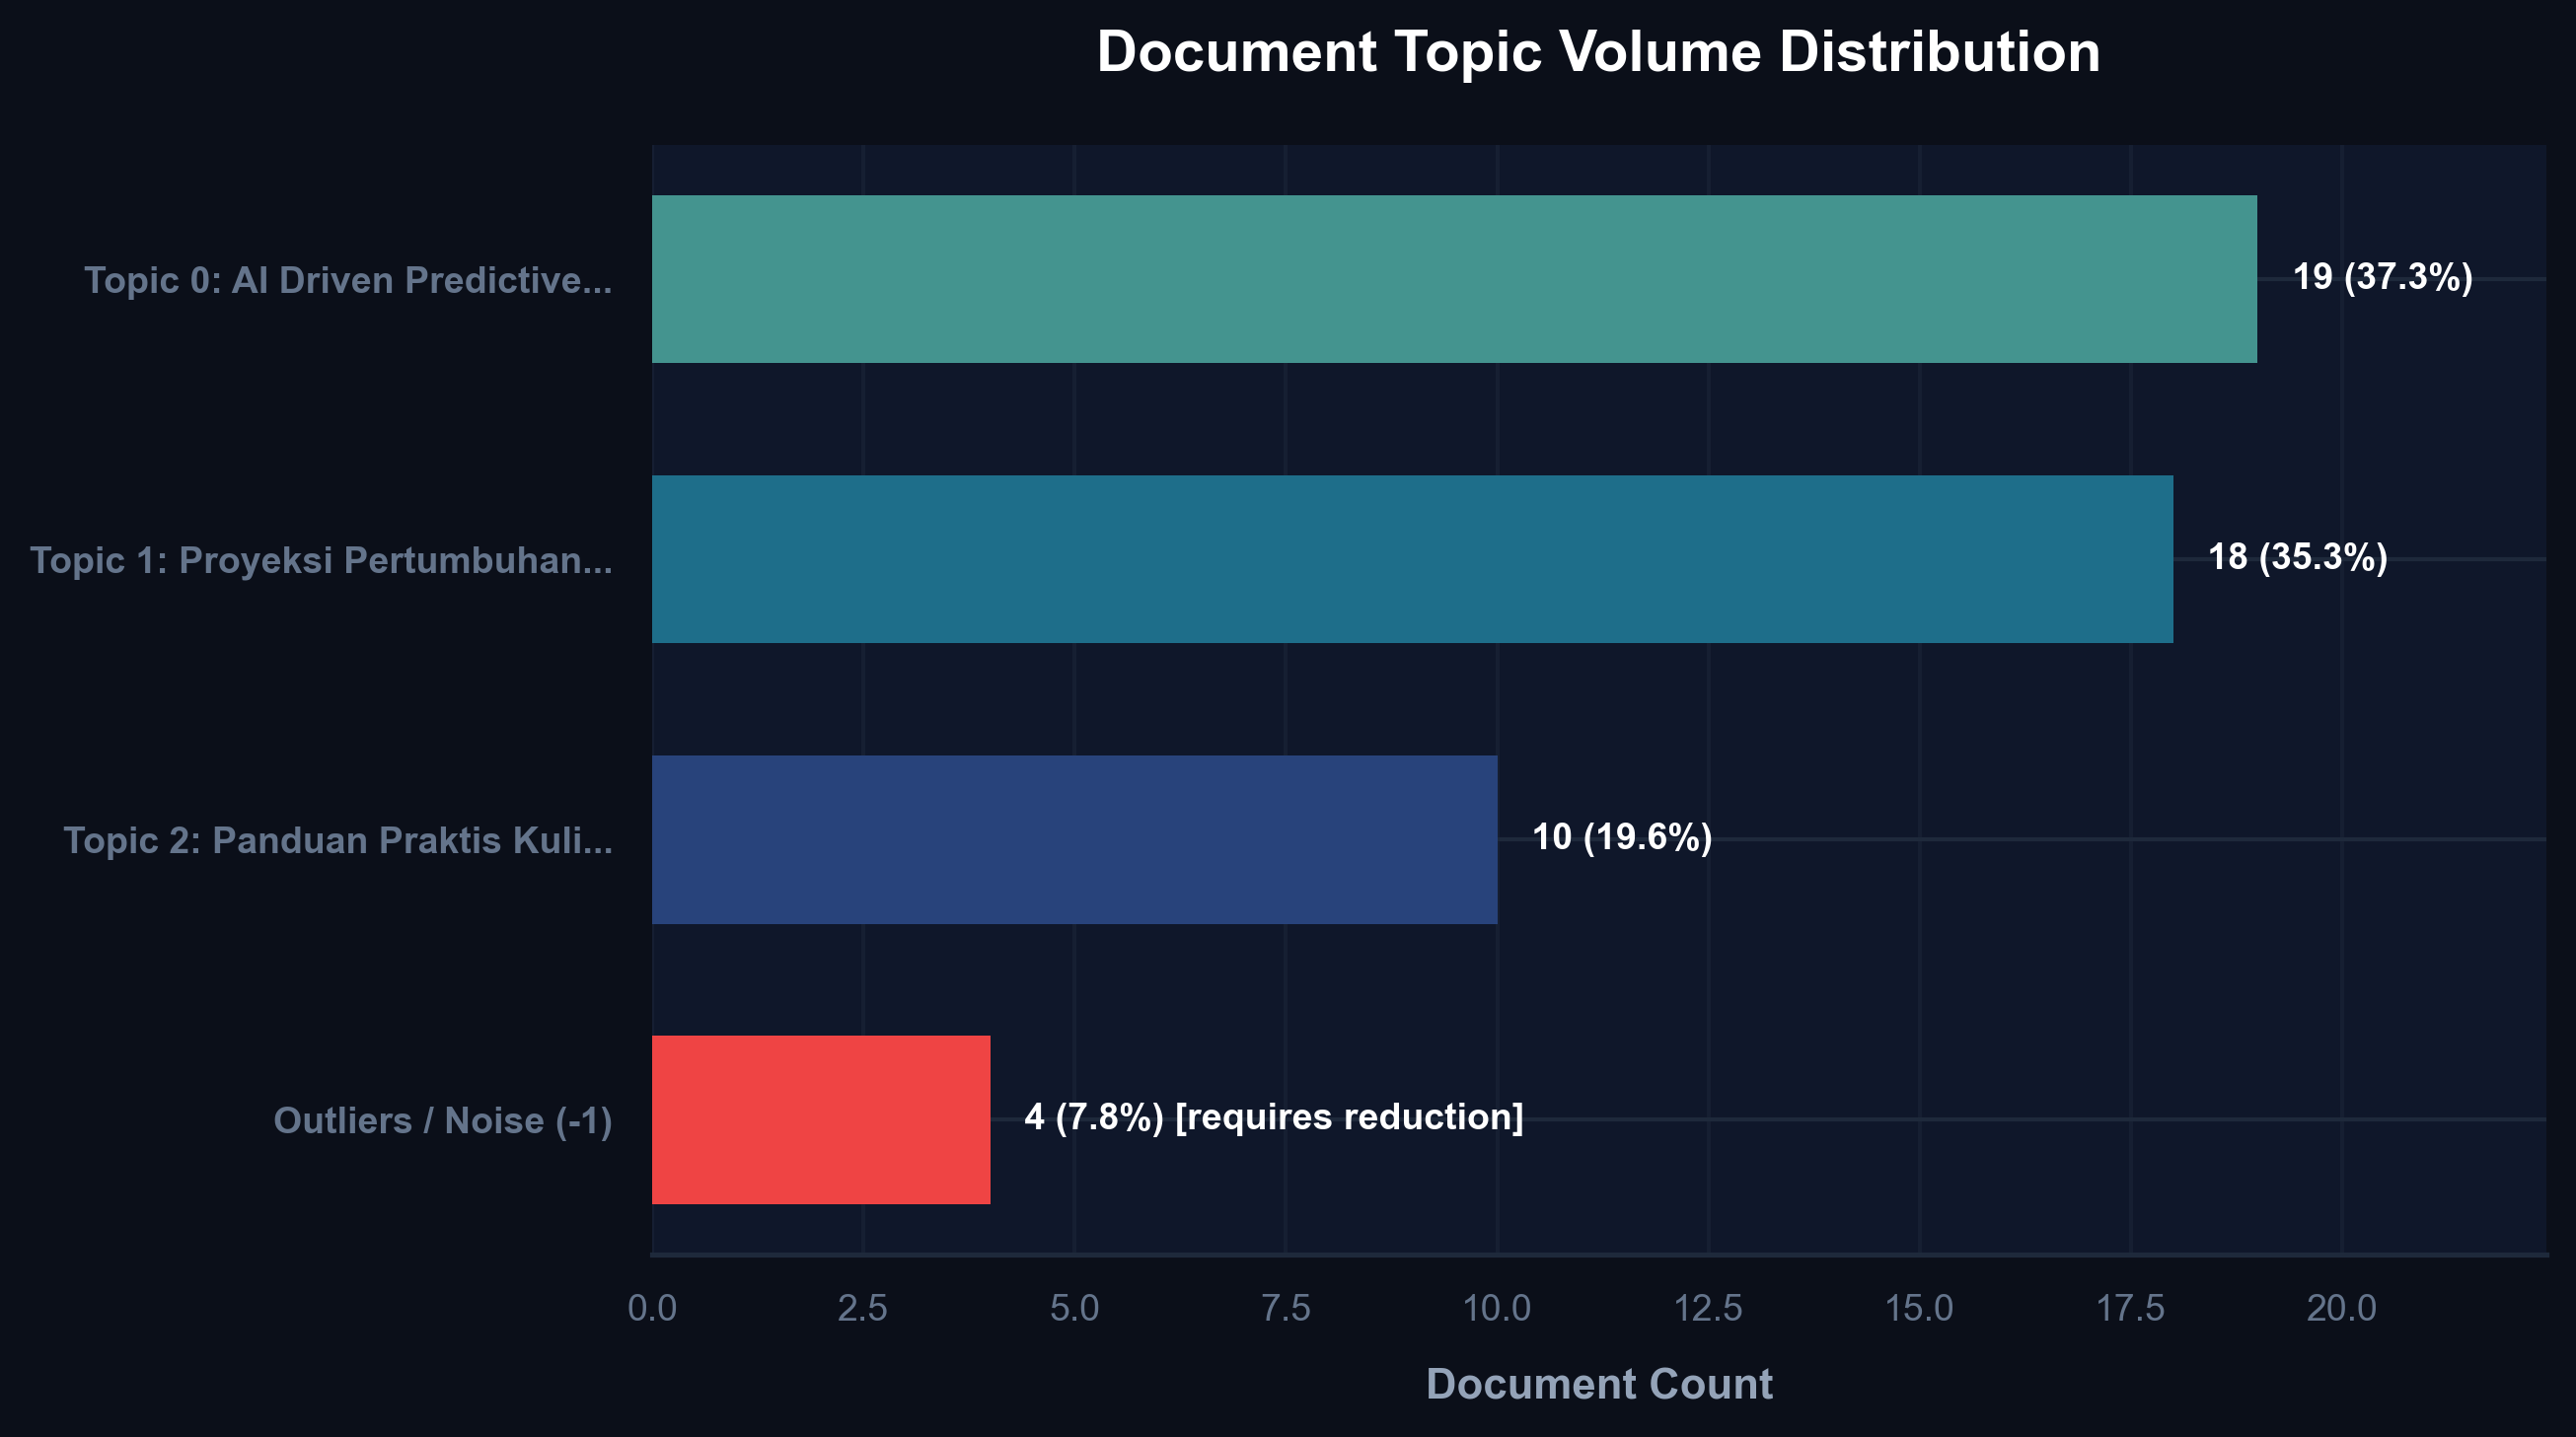
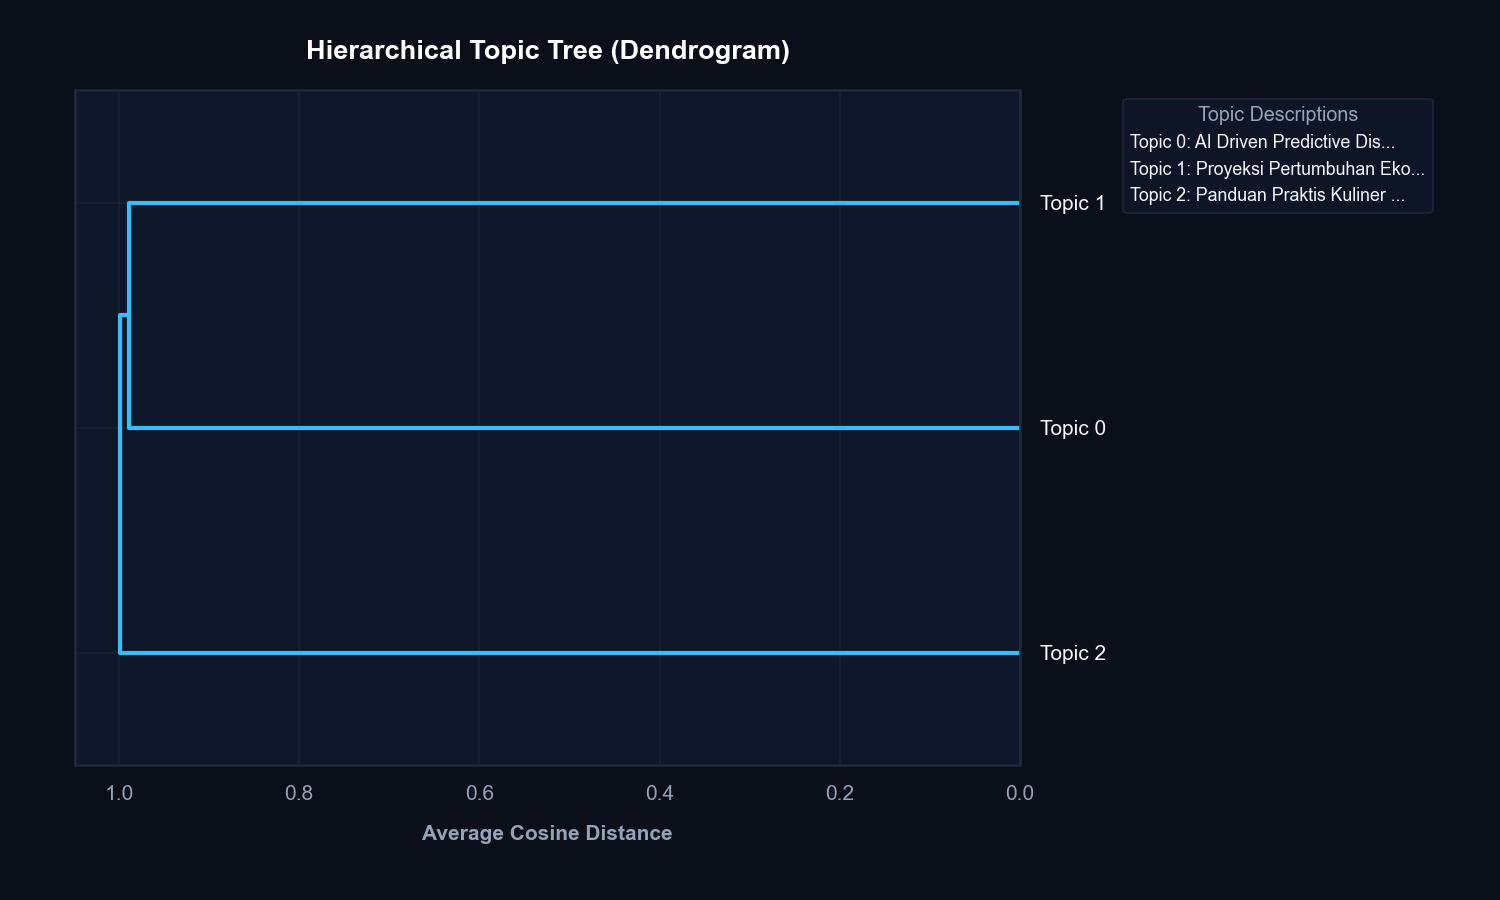
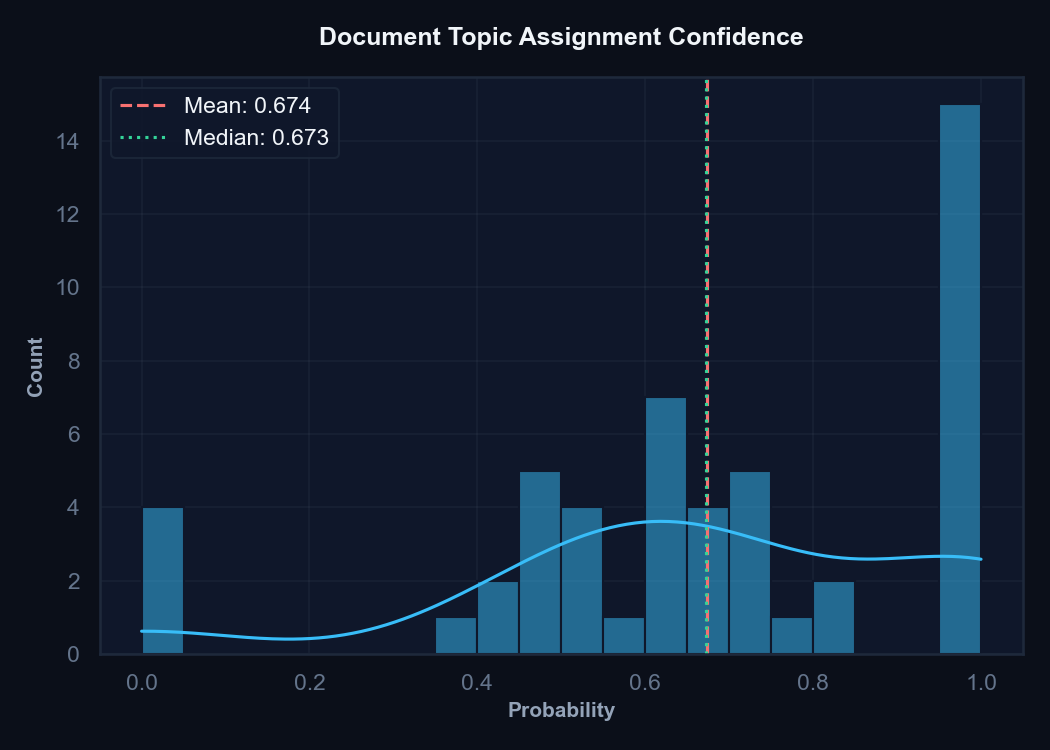
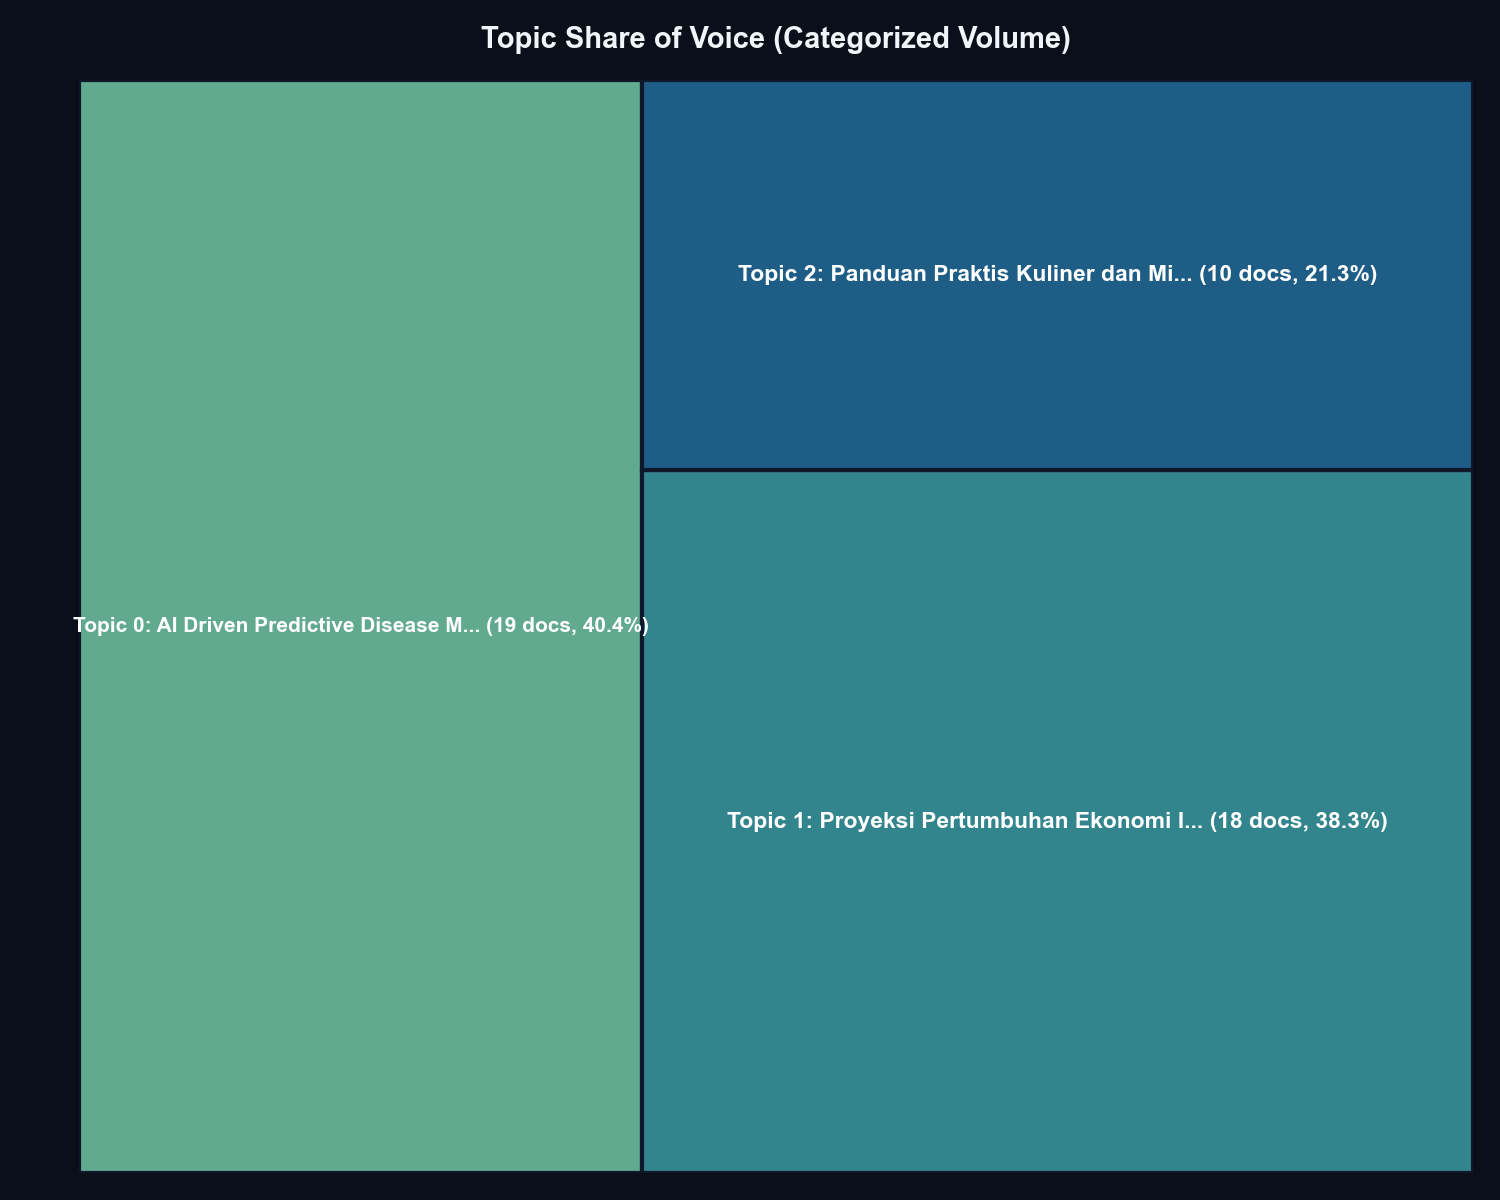
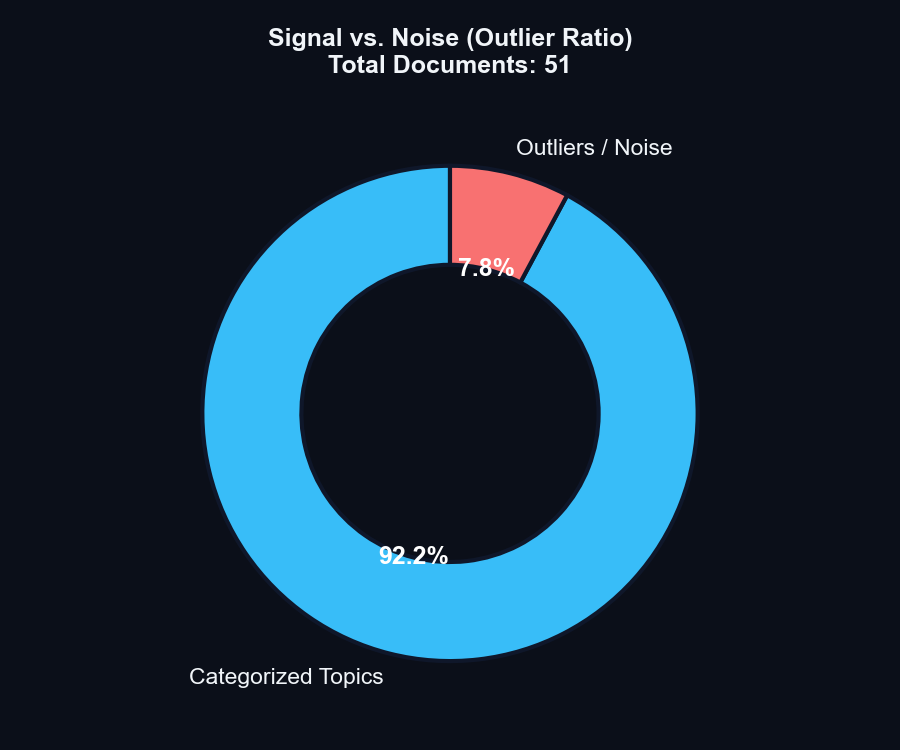
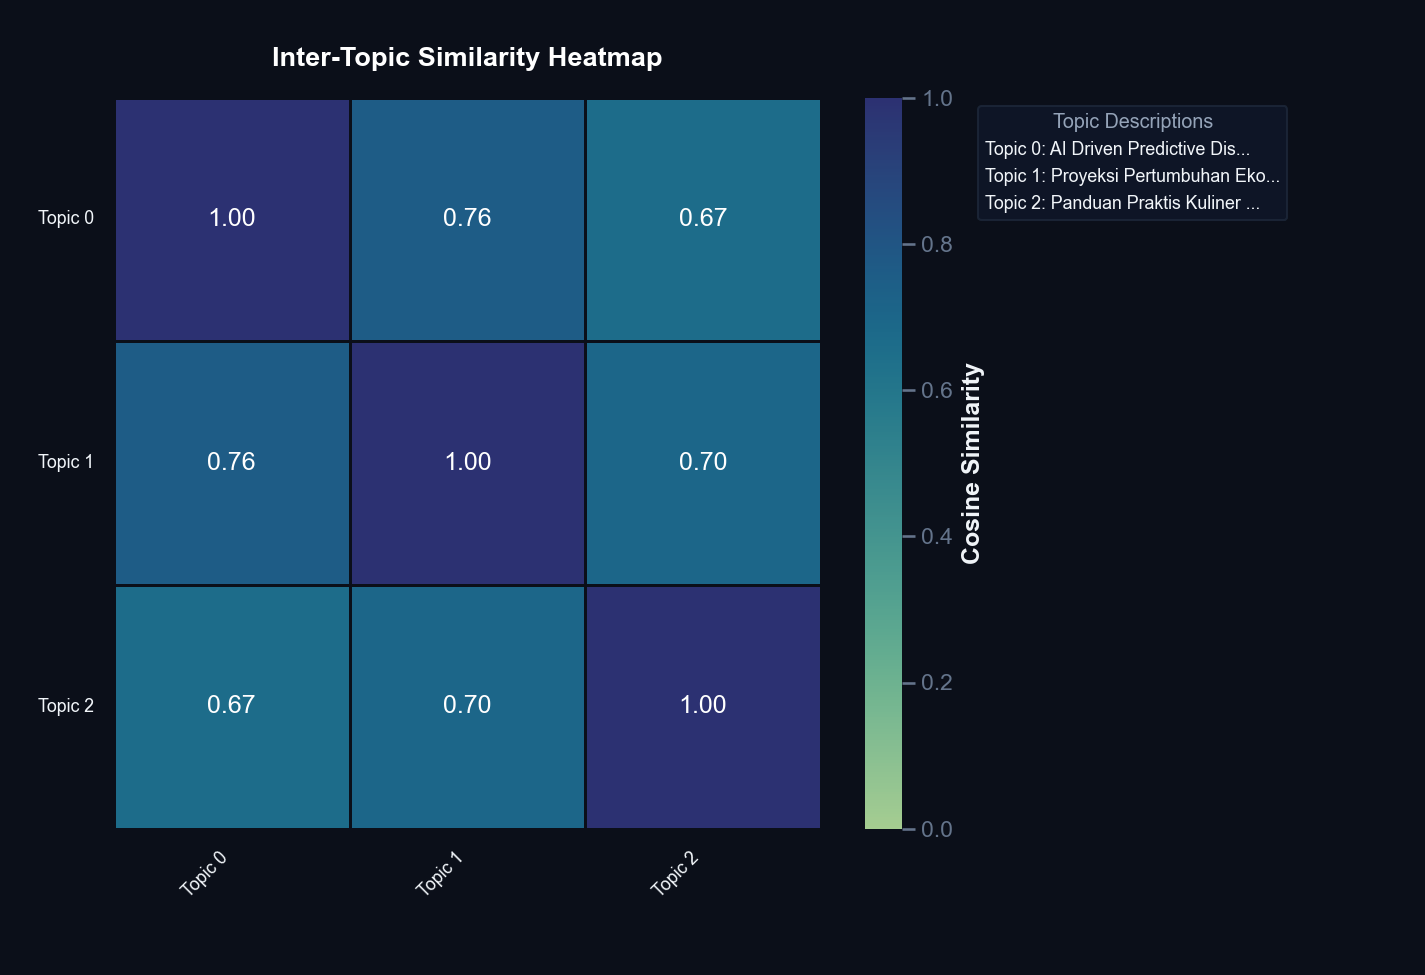
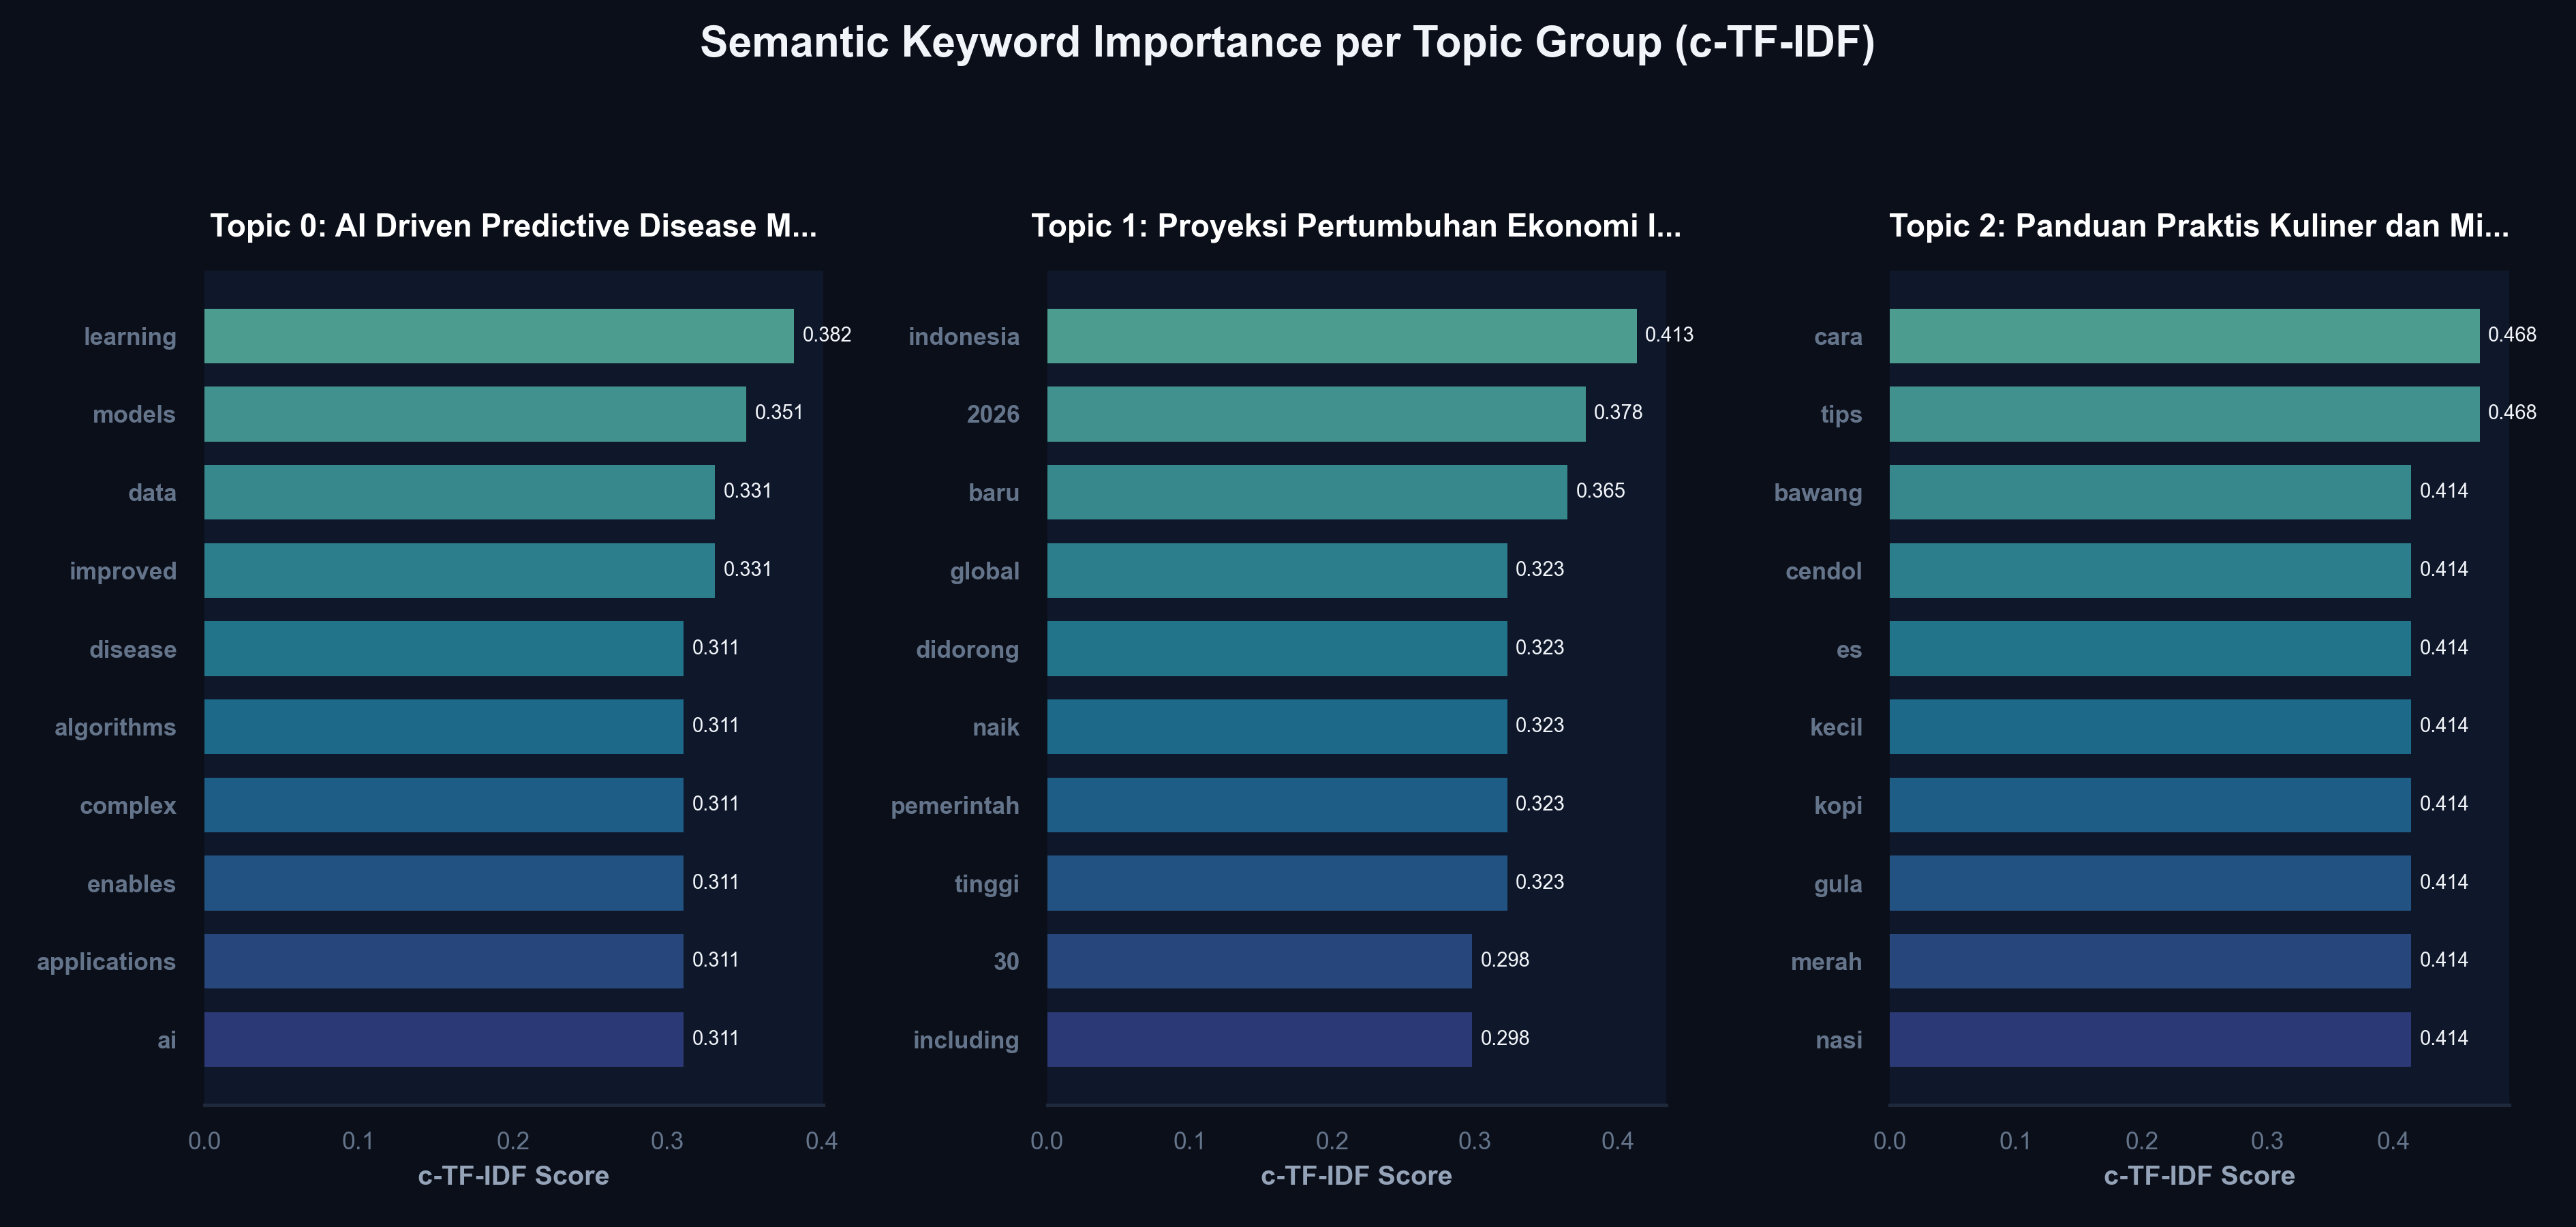
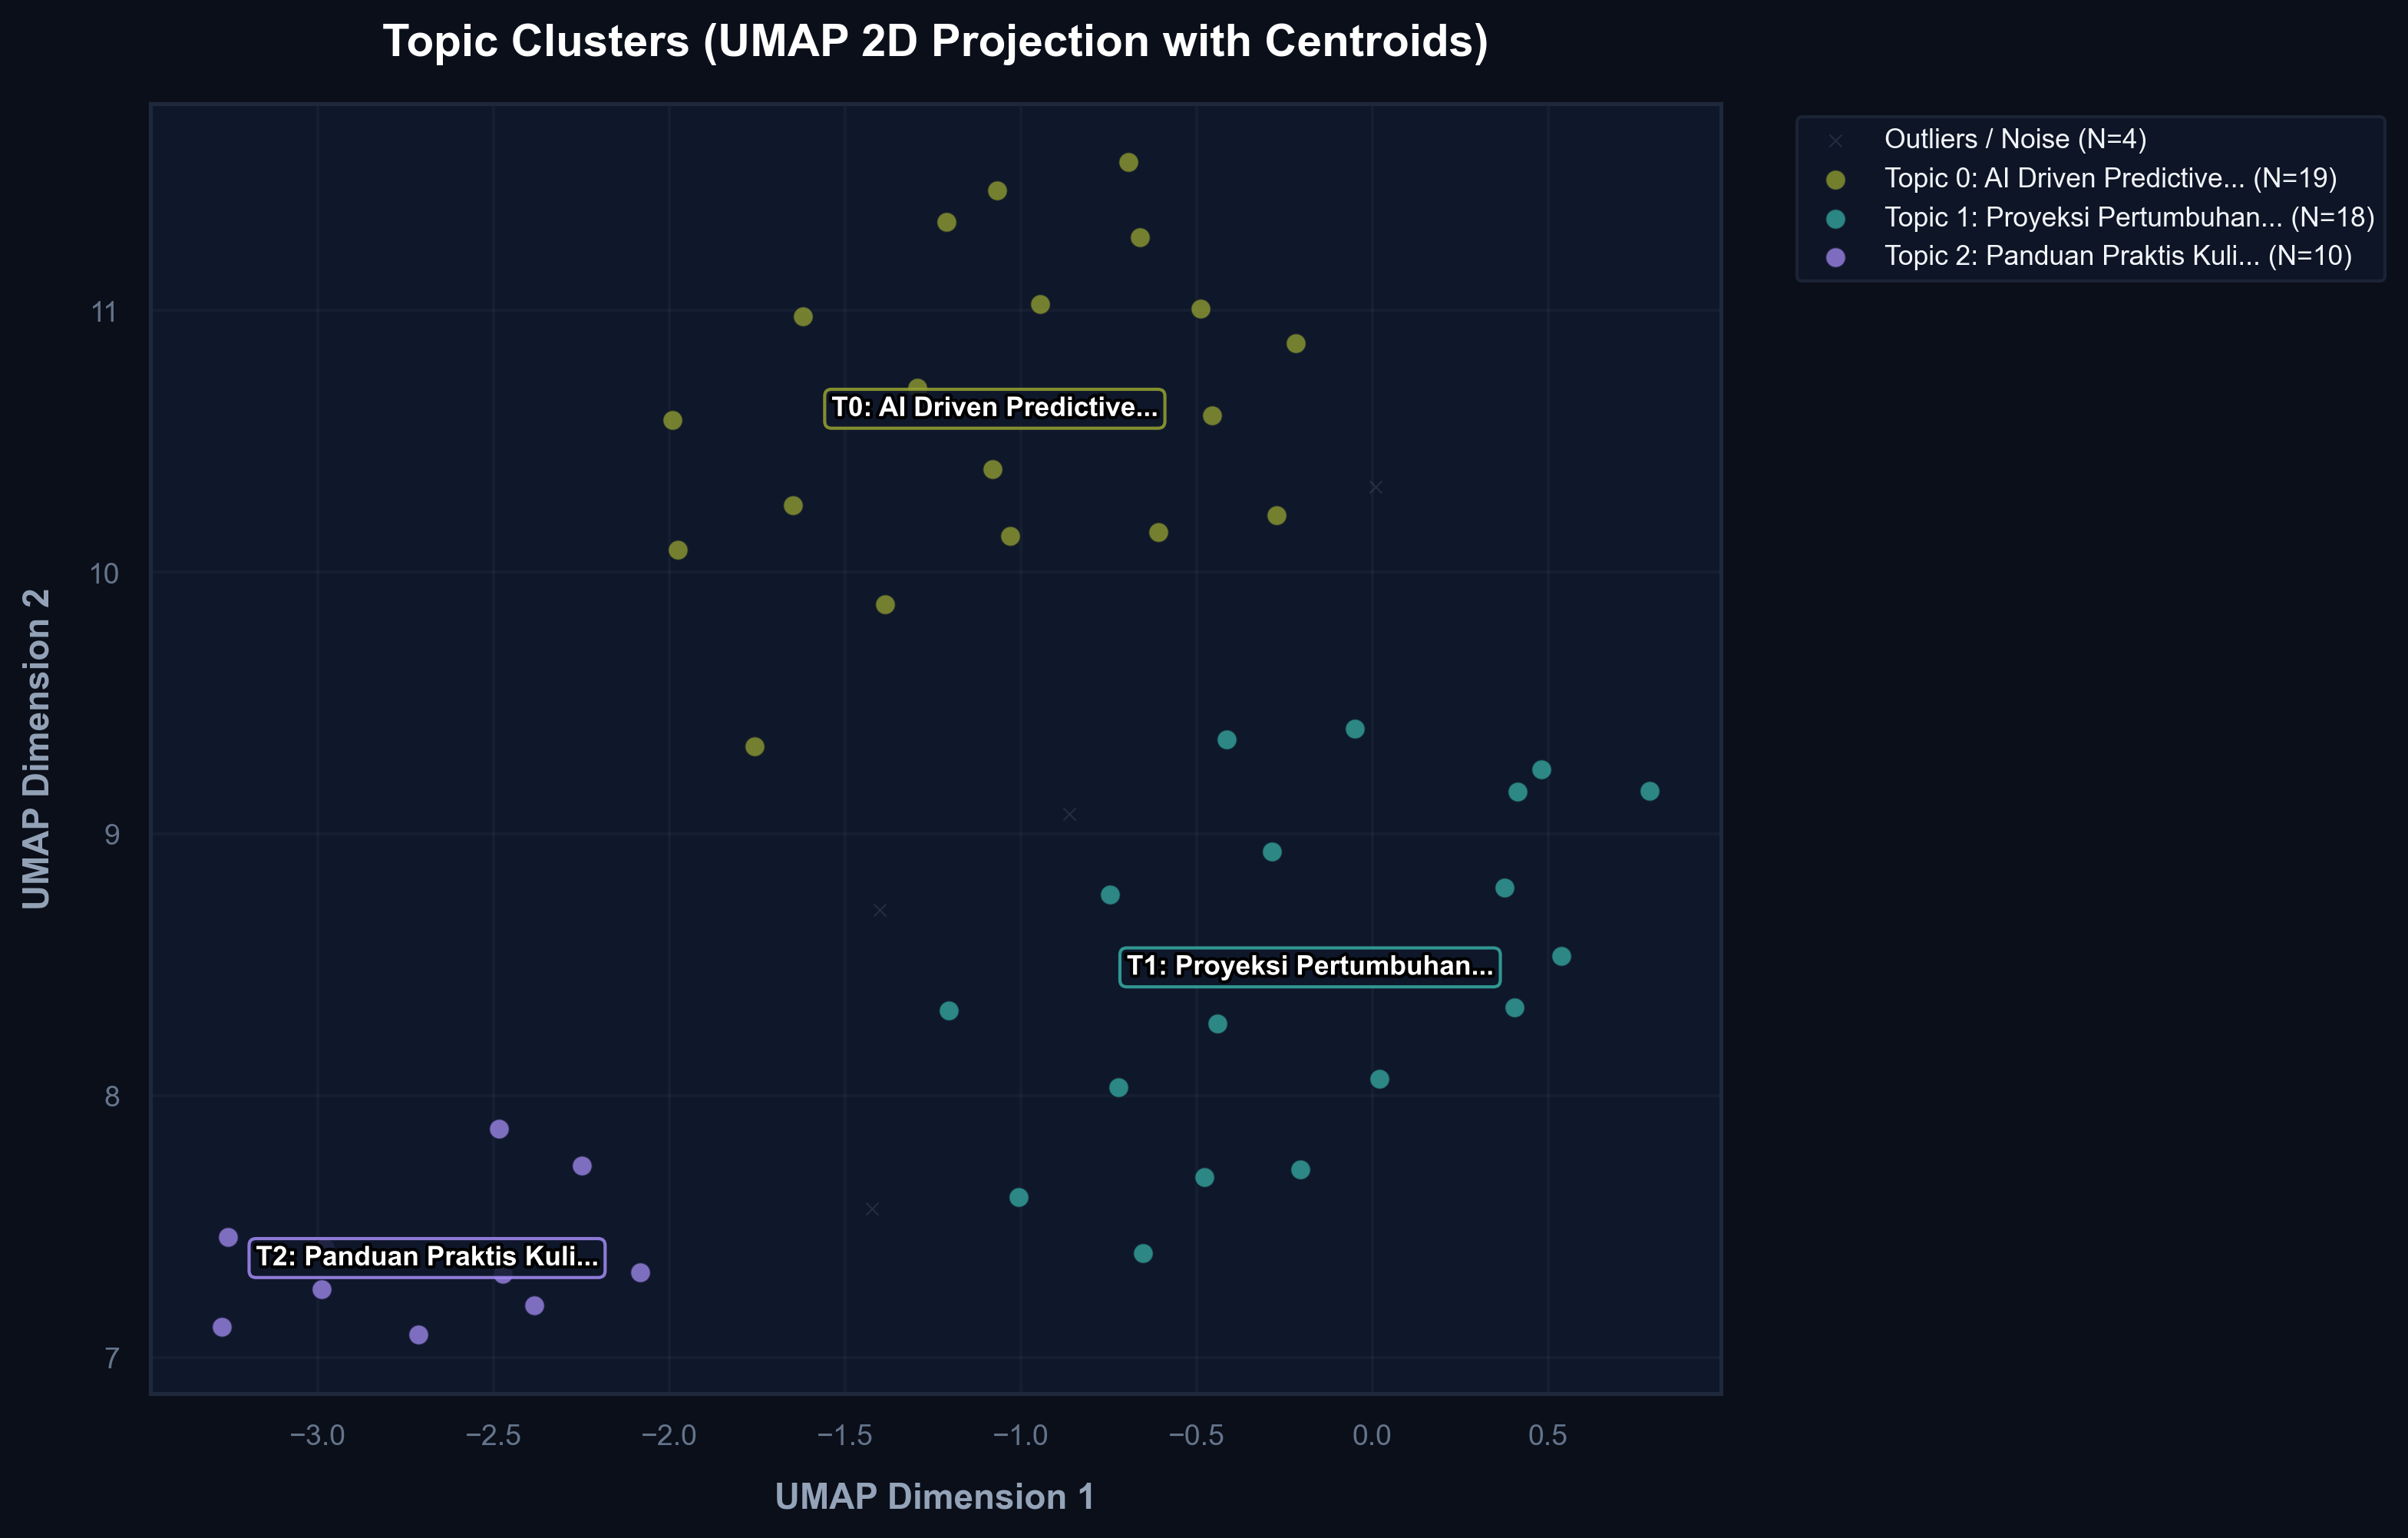

In [2]:
# ══════════════════════════════════════════════════════════════════════
#  Execute — Universal NLP Intelligence Pipeline
# ══════════════════════════════════════════════════════════════════════

from ml_engine import AutoMLFactory

factory = AutoMLFactory(AUTOML_CONFIG)
factory.execute_pipeline()

---
## 📤 Step 3: Batch Inference on Unseen Data (Supervised Mode Only)
For **Supervised NLP mode**, you can run batch prediction on new, unseen text data using the trained AutoGluon models. The engine automatically applies the same 15-step text cleaning pipeline.

> 💡 **Note on Zero-Shot and Unsupervised Modes**:
> For **Zero-Shot Classification** and **Unsupervised Topic Modeling**, this step is redundant. The engine already evaluates and labels the primary training dataset directly during the execution step (Step 2) and exports the results to the dashboard and CSV files.


In [3]:
# ══════════════════════════════════════════════════════════════════════
#  Batch Inference & Export (Supervised Mode Only)
# ══════════════════════════════════════════════════════════════════════

# If using Supervised NLP mode, uncomment to run predictions on unseen data:
# if AUTOML_CONFIG.get("target_column") and AUTOML_CONFIG.get("prediction_data_path"):
#     factory.predict_and_export()
